# Predict the Genre of a movie or TV - series

In [214]:
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from scipy.sparse import hstack
from wordcloud import WordCloud

## Understanding the data

In [215]:
df = pd.read_csv('../dataset/tv-shows.csv')
df.head(5)

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix
3,4,TV Show,The Returned,NaN,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix


In [216]:
df.shape

(9338, 13)

In [217]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9338 entries, 0 to 9337
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            9338 non-null   int64
 1   type          9338 non-null   str  
 2   title         9338 non-null   str  
 3   director      6483 non-null   str  
 4   cast          8400 non-null   str  
 5   country       8376 non-null   str  
 6   date_added    9325 non-null   str  
 7   release_year  9338 non-null   int64
 8   rating        9331 non-null   str  
 9   duration      9335 non-null   str  
 10  listed_in     9338 non-null   str  
 11  description   9338 non-null   str  
 12  platform      9338 non-null   str  
dtypes: int64(2), str(11)
memory usage: 948.5 KB


In [218]:
df.isnull().sum()

id                 0
type               0
title              0
director        2855
cast             938
country          962
date_added        13
release_year       0
rating             7
duration           3
listed_in          0
description        0
platform           0
dtype: int64

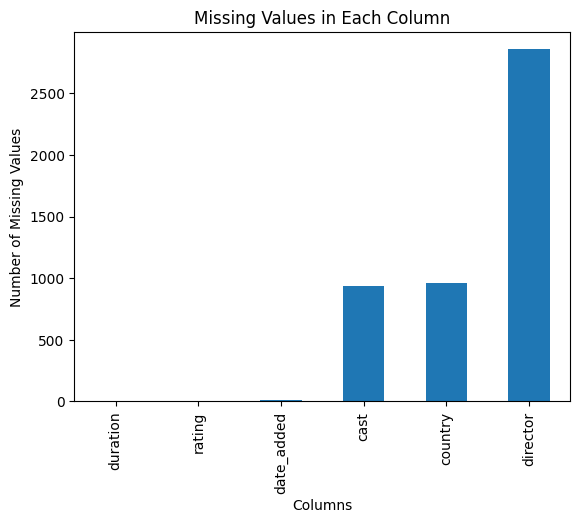

In [219]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(inplace=True)
missing_values.plot.bar()
plt.title('Missing Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.savefig('../plots/missing_values.png', bbox_inches='tight', dpi=300)
plt.show()

In [220]:
df['listed_in'].value_counts().head(25)

listed_in
Documentaries                                        322
Dramas, International Movies                         320
Stand-Up Comedy                                      307
Comedies, Dramas, International Movies               250
Dramas, Independent Movies, International Movies     225
Kids' TV                                             190
Children & Family Movies                             187
Children & Family Movies, Comedies                   171
Documentaries, International Movies                  169
Dramas, International Movies, Romantic Movies        164
Comedies, International Movies                       159
Comedies, International Movies, Romantic Movies      132
Dramas                                               125
Dramas, International Movies, Thrillers              122
Animation, Comedy, Family                            122
Action & Adventure                                   115
Action & Adventure, Dramas, International Movies     114
Comedies, Dramas, Ind

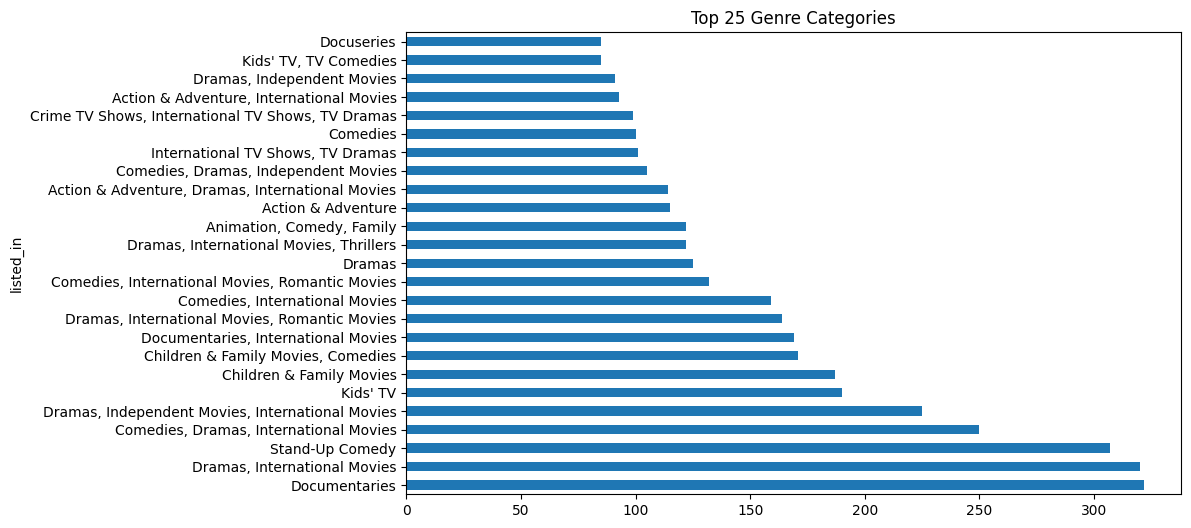

In [221]:
df["listed_in"].value_counts().head(25).plot(kind="barh",figsize=(10,6))

plt.title("Top 25 Genre Categories")
plt.savefig('../plots/top_genres.png', bbox_inches='tight', dpi=300)
plt.show()

In [222]:
df["type"].value_counts()

type
Movie      6528
TV Show    2810
Name: count, dtype: int64

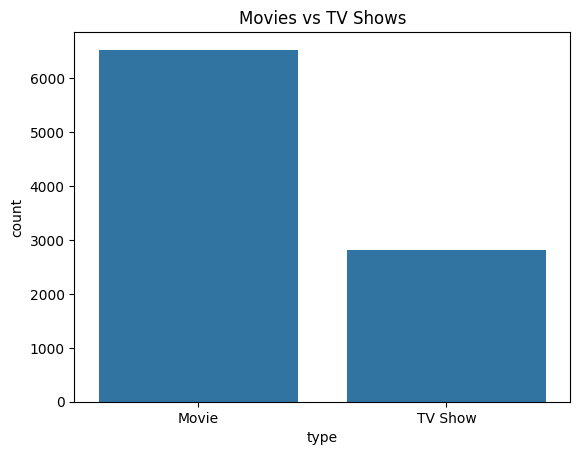

In [223]:
sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows")
plt.savefig('../plots/movies_vs_tvshows.png', bbox_inches='tight', dpi=300)
plt.show()

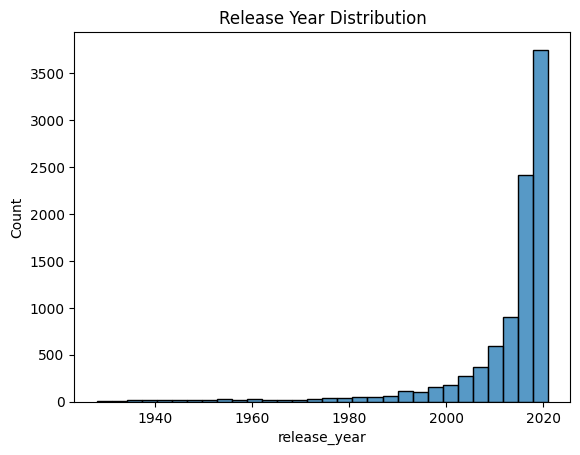

In [224]:
sns.histplot(df["release_year"], bins=30)

plt.title("Release Year Distribution")
plt.savefig('../plots/release_year_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

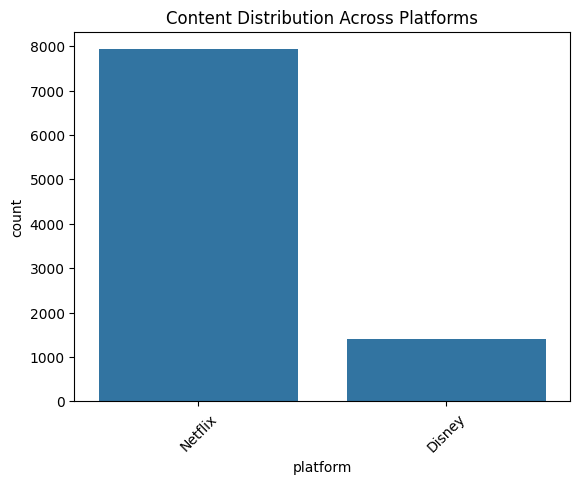

In [225]:
sns.countplot(x="platform", data=df)

plt.title("Content Distribution Across Platforms")
plt.xticks(rotation=45)
plt.savefig('../plots/content_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

In [226]:
print("Dataset Shape:", df.shape)

print("Unique Genre Categories:", df["listed_in"].nunique())

Dataset Shape: (9338, 13)
Unique Genre Categories: 825


## Preprocessing

In [227]:
genre_counts = df["listed_in"].value_counts()

frequent_genres = genre_counts[genre_counts >= 75].index

df_model = df[df["listed_in"].isin(frequent_genres)]

In [228]:
df_model["country"] = df_model["country"].fillna("Unknown")
df_model["rating"] = df_model["rating"].fillna("Unknown")
df_model["platform"] = df_model["platform"].fillna("Unknown")

In [229]:
df_model['director'] = df_model['director'].fillna('')
df_model['cast'] = df_model['cast'].fillna('')
df_model['title'] = df_model['title'].fillna('')

In [230]:
print("Dataset Shape:", df_model.shape)
print("Unique Genre Categories:", df_model["listed_in"].nunique())


Dataset Shape: (4436, 13)
Unique Genre Categories: 31


In [231]:
df_model["listed_in"].value_counts().head()

listed_in
Documentaries                                       322
Dramas, International Movies                        320
Stand-Up Comedy                                     307
Comedies, Dramas, International Movies              250
Dramas, Independent Movies, International Movies    225
Name: count, dtype: int64

In [232]:
df_model['combined_text'] = df_model['title'] + " " + df_model['director'] + " " + df_model['cast'] + " " + df_model['description']
X_text = df_model['combined_text']

X_cat = df_model[["type", "rating", "platform", "country"]]

y = df_model["listed_in"]

In [233]:
X_text_train, X_text_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_text,
    X_cat,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### TF-IDF

In [234]:
tfidf = TfidfVectorizer(
    stop_words='english', 
    max_features=25000,   # Increased to handle names and bi-grams smoothly
    ngram_range=(1, 2), 
    sublinear_tf=True
)

X_text_train_tfidf = tfidf.fit_transform(X_text_train)

X_text_test_tfidf = tfidf.transform(X_text_test)

### One Hot Encoder

In [235]:
encoder = OneHotEncoder(handle_unknown="ignore")

X_cat_train_enc = encoder.fit_transform(X_cat_train)

X_cat_test_enc = encoder.transform(X_cat_test)

In [236]:
X_train_final = hstack([
    X_text_train_tfidf,
    X_cat_train_enc
])

X_test_final = hstack([
    X_text_test_tfidf,
    X_cat_test_enc
])

In [237]:
print(X_train_final.shape)
print(X_test_final.shape)
print(len(y_train))
print(len(y_test))

(3548, 25425)
(888, 25425)
3548
888


## Train Model - Logisitic Regression

In [238]:
lr = LogisticRegression(max_iter=5000, C=50, class_weight='balanced')
lr.fit(X_train_final, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",50
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [239]:
pred_lr = lr.predict(X_test_final)

### Evaluate

In [240]:
lr_acc = accuracy_score(y_test,pred_lr)

print("Logistic Regression Accuracy:",lr_acc)

Logistic Regression Accuracy: 0.5472972972972973


In [241]:
print("===== Logistic Regression =====")
print(classification_report(y_test, pred_lr, zero_division=0))

===== Logistic Regression =====
                                                        precision    recall  f1-score   support

                                    Action & Adventure       0.50      0.61      0.55        23
      Action & Adventure, Dramas, International Movies       0.47      0.30      0.37        23
              Action & Adventure, International Movies       0.44      0.37      0.40        19
                   Action-Adventure, Animation, Comedy       0.82      0.60      0.69        15
                             Animation, Comedy, Family       0.79      0.92      0.85        24
                  Anime Series, International TV Shows       0.76      1.00      0.86        16
                              Children & Family Movies       0.91      0.78      0.84        37
                    Children & Family Movies, Comedies       0.68      0.82      0.75        34
                                              Comedies       0.29      0.20      0.24        20
       

## Train Model - Random Forest

In [242]:
rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)

rf.fit(X_train_final,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [243]:

pred_rf = rf.predict(X_test_final)

### Evaluate

In [244]:
rf_acc = accuracy_score(y_test,pred_rf)

print("Random Forest Accuracy:",rf_acc)

Random Forest Accuracy: 0.44819819819819817


In [245]:
print("\n===== Random Forest =====")
print(classification_report(y_test, pred_rf, zero_division=0))


===== Random Forest =====
                                                        precision    recall  f1-score   support

                                    Action & Adventure       0.34      0.43      0.38        23
      Action & Adventure, Dramas, International Movies       0.50      0.17      0.26        23
              Action & Adventure, International Movies       1.00      0.21      0.35        19
                   Action-Adventure, Animation, Comedy       1.00      0.53      0.70        15
                             Animation, Comedy, Family       0.75      1.00      0.86        24
                  Anime Series, International TV Shows       0.78      0.88      0.82        16
                              Children & Family Movies       0.88      0.62      0.73        37
                    Children & Family Movies, Comedies       0.61      0.68      0.64        34
                                              Comedies       1.00      0.10      0.18        20
            

## Train Model - Linear SVC

In [246]:
svm = LinearSVC(max_iter=5000, C=50, class_weight='balanced')

svm.fit(X_train_final, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",50
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo

In [247]:
pred_svm = svm.predict(X_test_final)

### Evaluate

In [248]:
svm_acc = accuracy_score(y_test, pred_svm)
print("SVM Accuracy:",svm_acc)

SVM Accuracy: 0.5506756756756757


In [249]:
print("\n===== Linear SVC =====")
print(classification_report(y_test, pred_svm, zero_division=0))


===== Linear SVC =====
                                                        precision    recall  f1-score   support

                                    Action & Adventure       0.52      0.57      0.54        23
      Action & Adventure, Dramas, International Movies       0.39      0.30      0.34        23
              Action & Adventure, International Movies       0.50      0.37      0.42        19
                   Action-Adventure, Animation, Comedy       1.00      0.60      0.75        15
                             Animation, Comedy, Family       0.80      1.00      0.89        24
                  Anime Series, International TV Shows       0.76      1.00      0.86        16
                              Children & Family Movies       0.91      0.78      0.84        37
                    Children & Family Movies, Comedies       0.72      0.91      0.81        34
                                              Comedies       0.31      0.25      0.28        20
               

## Compare all models

In [250]:
comparison = pd.DataFrame(
    {
        "Model":[
            "Logistic Regression",
            "Random Forest",
            "LinearSVC"
        ],
        "Accuracy":[
            lr_acc,
            rf_acc,
            svm_acc
        ]
    }
)

comparison

,Model,Accuracy
0,Logistic Regression,0.547297
1,Random Forest,0.448198
2,LinearSVC,0.550676


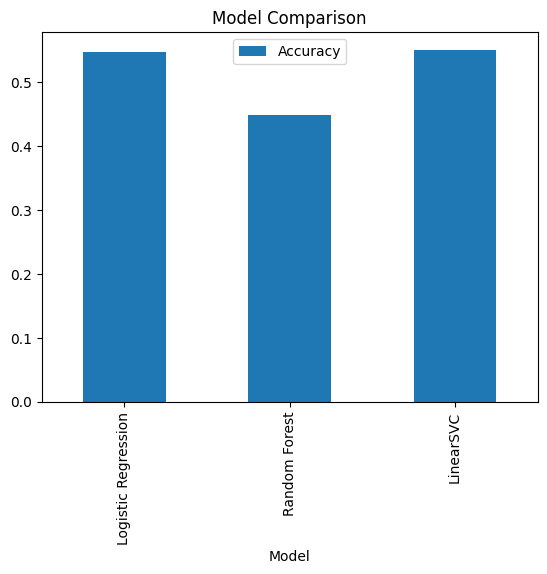

In [251]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Comparison")
plt.savefig('../plots/v1_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

## Explainability

In [252]:
text = " ".join(df_model["description"].astype(str))

In [253]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

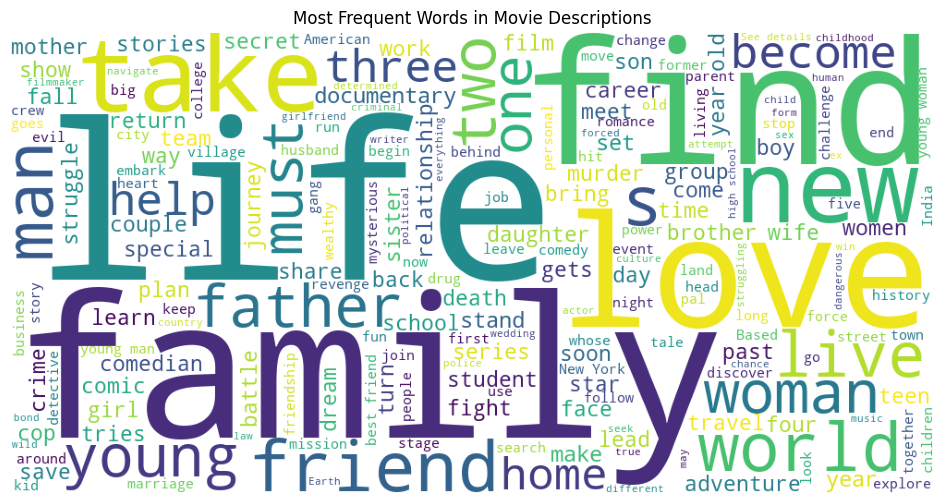

In [254]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Movie Descriptions")
plt.savefig('../plots/v1_wordcloud.png', bbox_inches='tight', dpi=300)
plt.show()

In [255]:
feature_names = tfidf.get_feature_names_out()

print("Total TF-IDF Features:", len(feature_names))
print(feature_names[:50])

Total TF-IDF Features: 25000
['000' '000 prize' '007' '009' '10' '10 000' '10 year' '100' '100 000'
 '11' '11 year' '12' '12 year' '12 years' '12th' '13' '13 david' '13 year'
 '13 years' '14' '14th' '15' '15 year' '15 years' '1590' '1590 wandering'
 '16' '16 year' '17' '17 year' '18' '18 beluga' '18 year' '1888' '18th'
 '18th century' '19' '1920s' '1930s' '1945' '1950s' '1960s' '1961' '1962'
 '1969' '1970s' '1971' '1975' '1976' '1978']
